In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\gayat\DATA VISUALIZATION\data_visualization\end_sem\AAPL_historical_data.csv")

In [4]:
print([{"label": label, "value": label} for label in df.columns])

[{'label': 'Date', 'value': 'Date'}, {'label': 'Open', 'value': 'Open'}, {'label': 'High', 'value': 'High'}, {'label': 'Low', 'value': 'Low'}, {'label': 'Close', 'value': 'Close'}]


In [3]:
df.head()

,Date,Open,High,Low,Close
0,1980-12-12 00:00:00-05:00,0.098834,0.099264,0.098834,0.098834
1,1980-12-15 00:00:00-05:00,0.094108,0.094108,0.093678,0.093678
2,1980-12-16 00:00:00-05:00,0.087232,0.087232,0.086802,0.086802
3,1980-12-17 00:00:00-05:00,0.088951,0.089381,0.088951,0.088951
4,1980-12-18 00:00:00-05:00,0.091530,0.091959,0.091530,0.091530


In [4]:
df.dtypes

Date      object
Open     float64
High     float64
Low      float64
Close    float64
dtype: object

In [5]:
df["Date"] = pd.to_datetime(df["Date"], utc = True)

In [6]:
df["Date"].dt.month.head(20)

0     12
1     12
2     12
3     12
4     12
5     12
6     12
7     12
8     12
9     12
10    12
11    12
12    12
13     1
14     1
15     1
16     1
17     1
18     1
19     1
Name: Date, dtype: int32

In [7]:
import regex as re

In [8]:
data = pd.read_csv(r"C:\Users\gayat\DATA VISUALIZATION\data_visualization\end_sem\India Agriculture Crop Production.csv")

In [9]:
data.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296


In [21]:
data["start"] = pd.to_datetime(data["Year"].str[:4], format = "%Y", utc = True)

In [22]:
data["end"] = pd.to_datetime((data["Year"].str[-2:].astype(int) + 2000).astype(str), format = "%Y", utc = True)

In [23]:
data.head()

,State,District,Crop,Year,Season,Area,Area Units,Production,Production Units,Yield,start,end
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,2001-02,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,2002-03,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,2003-04,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003-01-01 00:00:00+00:00,2004-01-01 00:00:00+00:00
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,2001-02,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,2002-03,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00


In [30]:
def extract_end_year(y):
    y = str(y)
    parts = y.split('-')
    if len(parts) == 2:
        start = int(parts[0])
        end_part = int(parts[1])

        # Handle 2-digit endings like '93', '17', '05'
        if end_part < 50:   # assume 2000s for 00–49
            end = 2000 + end_part
        else:               # assume 1900s for 50–99
            end = 1900 + end_part
    else:
        end = int(parts[0])
    return end

data["end"] = pd.to_datetime(data["Year"].apply(extract_end_year), format="%Y", utc=True)


In [31]:
modified_data = data.drop(columns = ["Year"])

In [46]:
modified_data.to_csv(r"C:\Users\gayat\DATA VISUALIZATION\data_visualization\end_sem\India_Agriculture_Crop_Production_Cleaned.csv", index = False)

In [47]:
modified_data.head()

,State,District,Crop,Season,Area,Area Units,Production,Production Units,Yield,start,end
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003-01-01 00:00:00+00:00,2004-01-01 00:00:00+00:00
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00


In [34]:
modified_data["start"].dt.year.min()

1997

In [35]:
modified_data["start"].dt.year.max()

2020

In [36]:
modified_data["end"].dt.year.min()

1998

In [37]:
modified_data["end"].dt.year.max()

2021

In [39]:
modified_data["Crop"].unique()

array(['Arecanut', 'Banana', 'Black pepper', 'Cashewnut', 'Coconut',
       'Dry chillies', 'Ginger', 'Other Kharif pulses', 'other oilseeds',
       'Rice', 'Sugarcane', 'Sweet potato', 'Arhar/Tur', 'Bajra',
       'Castor seed', 'Coriander', 'Cotton(lint)', 'Gram', 'Groundnut',
       'Horse-gram', 'Jowar', 'Linseed', 'Maize', 'Mesta',
       'Moong(Green Gram)', 'Niger seed', 'Onion', 'Other Rabi pulses',
       'Potato', 'Ragi', 'Rapeseed &Mustard', 'Safflower', 'Sesamum',
       'Small millets', 'Soyabean', 'Sunflower', 'Tapioca', 'Tobacco',
       'Turmeric', 'Urad', 'Wheat', 'Oilseeds total', 'Jute', 'Masoor',
       'Peas & beans (Pulses)', 'Barley', 'Garlic', 'Khesari', 'Sannhamp',
       'Guar seed', 'Moth', 'Cardamom', 'Other Cereals', 'Cowpea(Lobia)',
       'Dry Ginger', 'Other Summer Pulses', nan], dtype=object)

In [40]:
modified_data["Season"].unique()

array(['Kharif', 'Whole Year', 'Rabi', 'Autumn', 'Summer', 'Winter', nan],
      dtype=object)

In [45]:
modified_data.isnull().sum()

State               0
District            0
Crop                0
Season              0
Area                0
Area Units          0
Production          0
Production Units    0
Yield               0
start               0
end                 0
dtype: int64

In [44]:
modified_data = modified_data.dropna()

In [64]:
dataset_1 = modified_data.copy(deep = True)
dataset_1 = dataset_1.groupby("Crop")

In [60]:
dataset_1.head()

,State,District,Crop,Season,Area,Area Units,Production,Production Units,Yield,start,end
0,Andaman and Nicobar Islands,NICOBARS,Arecanut,Kharif,1254.0,Hectare,2061.0,Tonnes,1.643541,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
1,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,1258.0,Hectare,2083.0,Tonnes,1.655803,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00
2,Andaman and Nicobar Islands,NICOBARS,Arecanut,Whole Year,1261.0,Hectare,1525.0,Tonnes,1.209358,2003-01-01 00:00:00+00:00,2004-01-01 00:00:00+00:00
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,Arecanut,Kharif,3100.0,Hectare,5239.0,Tonnes,1.690000,2001-01-01 00:00:00+00:00,2002-01-01 00:00:00+00:00
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,Arecanut,Whole Year,3105.0,Hectare,5267.0,Tonnes,1.696296,2002-01-01 00:00:00+00:00,2003-01-01 00:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...,...
252899,Maharashtra,AHMEDNAGAR,Other Summer Pulses,Summer,100.0,Hectare,100.0,Tonnes,1.000000,2016-01-01 00:00:00+00:00,2017-01-01 00:00:00+00:00
252900,Maharashtra,AHMEDNAGAR,Other Summer Pulses,Summer,20.0,Hectare,4.0,Tonnes,0.200000,2017-01-01 00:00:00+00:00,2018-01-01 00:00:00+00:00
252901,Maharashtra,AHMEDNAGAR,Other Summer Pulses,Summer,17.0,Hectare,17.0,Tonnes,1.000000,2018-01-01 00:00:00+00:00,2019-01-01 00:00:00+00:00
252902,Maharashtra,AMRAVATI,Other Summer Pulses,Summer,400.0,Hectare,200.0,Tonnes,0.500000,2016-01-01 00:00:00+00:00,2017-01-01 00:00:00+00:00


In [62]:
modified_data.columns

Index(['State', 'District', 'Crop', 'Season', 'Area', 'Area Units',
       'Production', 'Production Units', 'Yield', 'start', 'end'],
      dtype='object')

In [53]:
type(dataset_1)

pandas.core.series.Series

In [ ]:
data_frame_1.head()

,Production
Crop,
Arecanut,3.929935e+07
Arhar/Tur,6.126133e+07
Bajra,2.006659e+08
Banana,2.271978e+08
Barley,3.506932e+07


In [58]:
data_frame_1.index

Index(['Arecanut', 'Arhar/Tur', 'Bajra', 'Banana', 'Barley', 'Black pepper',
       'Cardamom', 'Cashewnut', 'Castor seed', 'Coconut', 'Coriander',
       'Cotton(lint)', 'Cowpea(Lobia)', 'Dry Ginger', 'Dry chillies', 'Garlic',
       'Ginger', 'Gram', 'Groundnut', 'Guar seed', 'Horse-gram', 'Jowar',
       'Jute', 'Khesari', 'Linseed', 'Maize', 'Masoor', 'Mesta',
       'Moong(Green Gram)', 'Moth', 'Niger seed', 'Oilseeds total', 'Onion',
       'Other Cereals', 'Other Kharif pulses', 'Other Rabi pulses',
       'Other Summer Pulses', 'Peas & beans (Pulses)', 'Potato', 'Ragi',
       'Rapeseed &Mustard', 'Rice', 'Safflower', 'Sannhamp', 'Sesamum',
       'Small millets', 'Soyabean', 'Sugarcane', 'Sunflower', 'Sweet potato',
       'Tapioca', 'Tobacco', 'Turmeric', 'Urad', 'Wheat', 'other oilseeds'],
      dtype='object', name='Crop')

In [70]:
x = [4,5,5,6,7,7,9,10]
bin = 2
px.histogram(data_frame = x)


In [66]:
import plotly.express as px

In [ ]:
px.histogram()

In [68]:
import matplotlib.pyplot as plt

(array([4., 4.]), array([ 4.,  7., 10.]), <BarContainer object of 2 artists>)

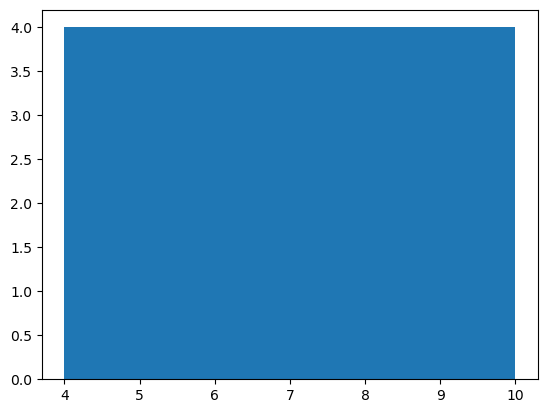

In [69]:
plt.hist(x, bins = 2)